# Churn Prediction – Classification Pipeline
**Models:** Logistic Regression & Decision Tree  
**Target:** Churn (0 = Ở lại | 1 = Rời bỏ)  
**Metrics:** Precision, Recall, F1-Score, ROC-AUC  

---
Bài toán: Dự báo khách hàng rời bỏ hệ thống

Mô tả dữ liệu:
- CustomerID: Mã định danh duy nhất của mỗi khách hàng.

- Total_Spend (Monetary): Tổng số tiền mà khách hàng đã chi tiêu tại cửa hàng/hệ thống.

- Frequency: Tần suất mua sắm (tổng số lần khách hàng thực hiện các đơn hàng khác nhau).

- Total_Items: Tổng số lượng sản phẩm vật lý mà khách hàng đã mua cộng dồn lại.

- Unique_Products: Độ đa dạng khi mua sắm (số lượng các mặt hàng/mã sản phẩm khác nhau mà khách hàng đã chọn).

- Avg_Basket_Value: Giá trị trung bình của mỗi đơn hàng. Công thức tính là: Total_Spend / Frequency.

- Churn (Biến mục tiêu - Target): Trạng thái rời bỏ của khách hàng.

0: Khách hàng vẫn đang tiếp tục mua sắm (Retained).

1: Khách hàng đã ngừng mua sắm hoặc rời bỏ hệ thống (Churned).

## Cài đặt thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE


---
## Step 1 – Problem Understanding

| Mục | Nội dung |
|-----|----------|
| Bài toán | Phân loại khách hàng Churn (rời bỏ) hay không |
| Target | Churn: 0 = Ở lại, 1 = Rời bỏ |
| Loại | Binary Classification |
| Features | Total_Spend, Frequency, Total_Items, Unique_Products, Avg_Basket_Value |

  - **Precision**: Trong số dự đoán Churn, bao nhiêu đúng?
  - **Recall**: Trong số Churn thật, mô hình bắt được bao nhiêu?
  - **F1-Score**: Trung bình điều hòa của Precision & Recall

---
## Step 2 – Data Understanding

In [3]:
df = pd.read_csv("classification_data.csv")

print(f"Shape: {df.shape}")
print(f"\nCác cột:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (3601, 7)

Các cột:
CustomerID            int64
Total_Spend         float64
Frequency             int64
Total_Items           int64
Unique_Products       int64
Avg_Basket_Value    float64
Churn                 int64
dtype: object

Missing values:
CustomerID          0
Total_Spend         0
Frequency           0
Total_Items         0
Unique_Products     0
Avg_Basket_Value    0
Churn               0
dtype: int64


,CustomerID,Total_Spend,Frequency,Total_Items,Unique_Products,Avg_Basket_Value,Churn
0,12346,77183.60,1,74215,1,77183.600,1
1,12347,2790.86,5,1590,82,558.172,0
2,12348,1437.24,4,2332,21,359.310,1
3,12350,294.40,1,196,16,294.400,1
4,12352,1154.01,6,401,45,192.335,0


In [4]:
print("Thống kê mô tả:")
display(df.describe())

print("\nPhân phối Target (Churn):")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

Thống kê mô tả:


,CustomerID,Total_Spend,Frequency,Total_Items,Unique_Products,Avg_Basket_Value,Churn
count,3601.000000,3601.000000,3601.000000,3601.000000,3601.000000,3601.000000,3601.000000
mean,15274.502083,1680.373941,3.614274,994.916968,52.044710,405.530549,0.487365
std,1723.169318,6934.406737,6.043114,4072.857697,71.867339,1387.520019,0.499910
min,12346.000000,2.900000,1.000000,1.000000,1.000000,2.900000,0.000000
25%,13778.000000,280.550000,1.000000,139.000000,14.000000,173.900000,0.000000
50%,15245.000000,590.000000,2.000000,331.000000,31.000000,289.240000,0.000000
75%,16756.000000,1412.060000,4.000000,820.000000,65.000000,425.320000,1.000000
max,18287.000000,202443.640000,136.000000,143851.000000,1462.000000,77183.600000,1.000000



Phân phối Target (Churn):
Churn
0    1846
1    1755
Name: count, dtype: int64
Churn
0    51.3%
1    48.7%
Name: proportion, dtype: object


Total_Spend:
  Số lượng outlier: 329
  Tỷ lệ outlier: 9.14%
----------------------------------------
Frequency:
  Số lượng outlier: 291
  Tỷ lệ outlier: 8.08%
----------------------------------------
Total_Items:
  Số lượng outlier: 341
  Tỷ lệ outlier: 9.47%
----------------------------------------
Unique_Products:
  Số lượng outlier: 260
  Tỷ lệ outlier: 7.22%
----------------------------------------
Avg_Basket_Value:
  Số lượng outlier: 252
  Tỷ lệ outlier: 7.00%
----------------------------------------


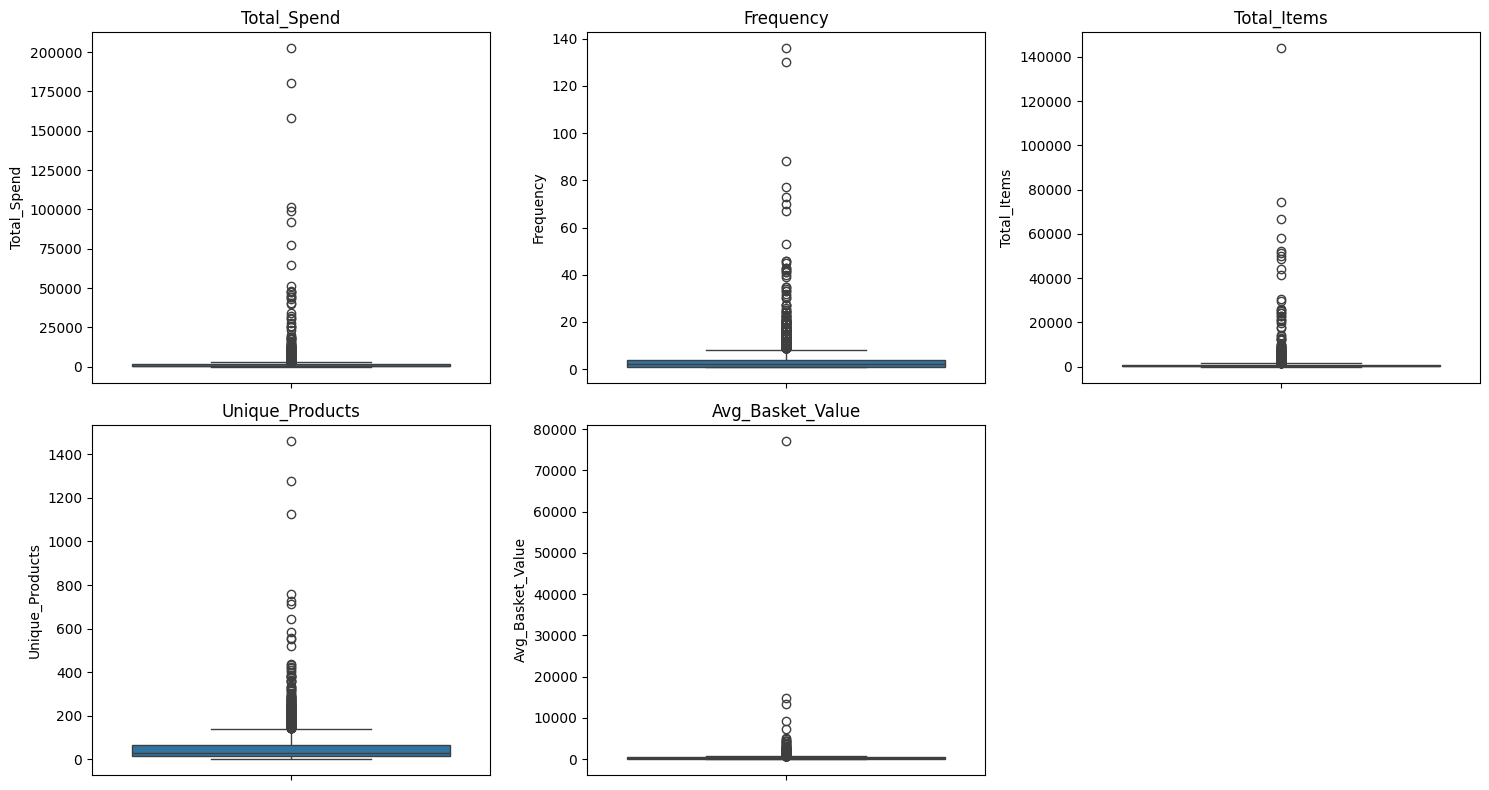

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'Total_Spend',
    'Frequency',
    'Total_Items',
    'Unique_Products',
    'Avg_Basket_Value'
]
# tỷ lệ giá trị outlier
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}:")
    print(f"  Số lượng outlier: {len(outliers)}")
    print(f"  Tỷ lệ outlier: {len(outliers)/len(df)*100:.2f}%")
    print("-" * 40)

# Biểu đồ boxplot
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

---
##Step 3 – Feature Understanding (EDA)

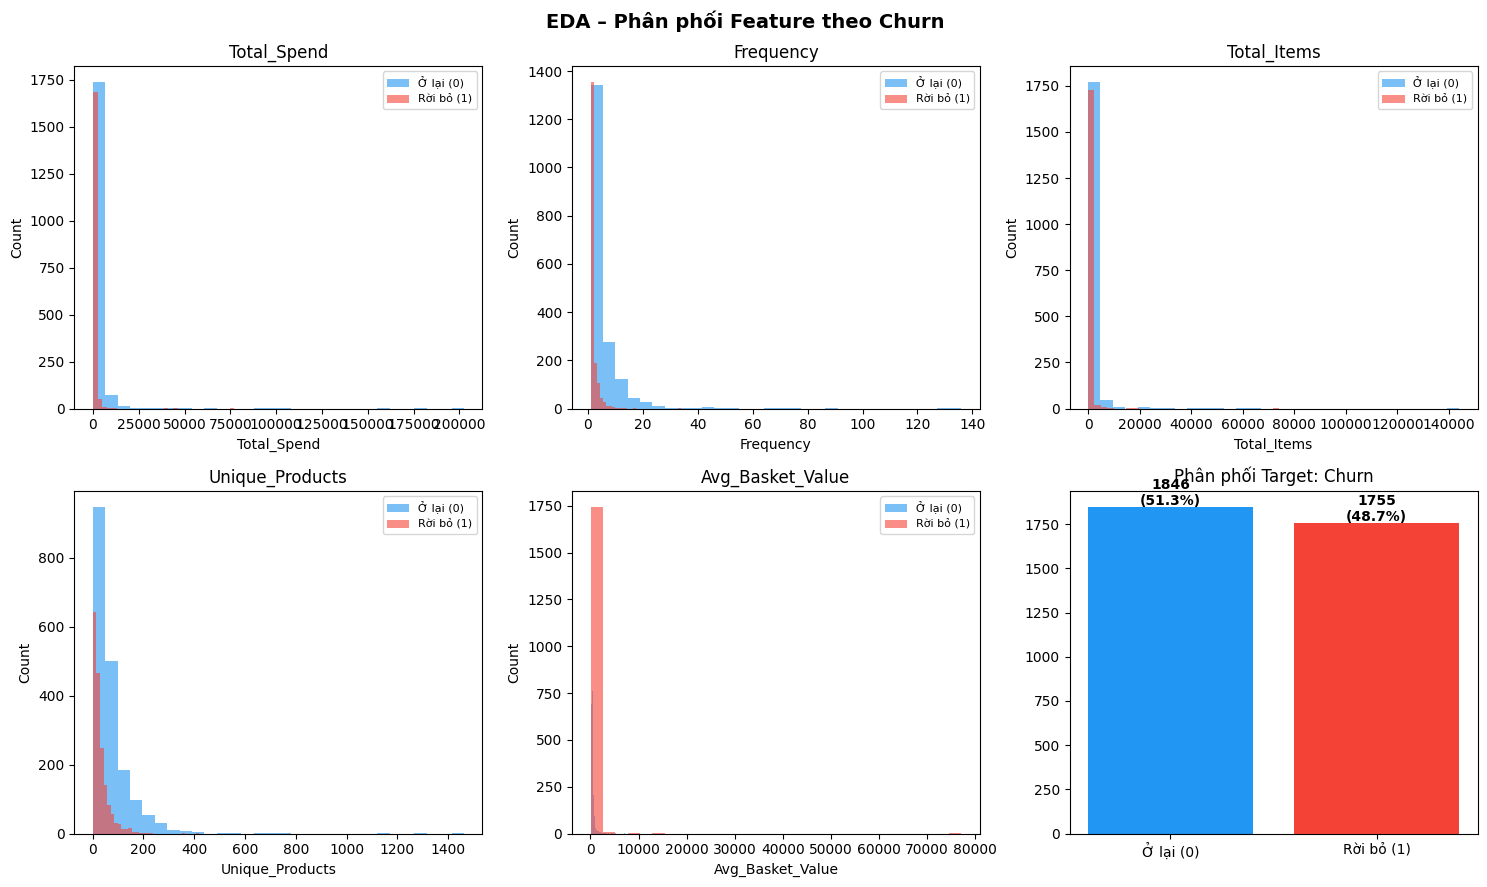

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("EDA – Phân phối Feature theo Churn", fontsize=14, fontweight="bold")

features = ["Total_Spend", "Frequency", "Total_Items", "Unique_Products", "Avg_Basket_Value"]
colors = ["#2196F3", "#F44336"]

for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    for churn_val, color, label in zip([0, 1], colors, ["Ở lại (0)", "Rời bỏ (1)"]):
        ax.hist(df[df["Churn"] == churn_val][feat], bins=30, alpha=0.6, color=color, label=label)
    ax.set_title(feat)
    ax.legend(fontsize=8)
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")

# Biểu đồ tỉ lệ Churn
ax_last = axes[1][2]
churn_counts = df["Churn"].value_counts()
ax_last.bar(["Ở lại (0)", "Rời bỏ (1)"], churn_counts.values, color=colors)
ax_last.set_title("Phân phối Target: Churn")
for idx, val in enumerate(churn_counts.values):
    ax_last.text(idx, val + 10, f"{val}\n({val/len(df):.1%})", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

---
## Step 4 – Feature Engineering

In [7]:
# Loại bỏ CustomerID (không có ý nghĩa dự đoán)
df = df.drop(columns=["CustomerID"])

X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"Features sử dụng: {X.columns.tolist()}")
print(f"Missing values  : {X.isnull().sum().sum()}")

print("\nSkewness của từng feature:")
for col in X.columns:
    sk = X[col].skew()
    flag = "Lệch cao" if abs(sk) > 1 else " OK"
    print(f"  {col:25s}: {sk:6.2f}  {flag}")

Features sử dụng: ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']
Missing values  : 0

Skewness của từng feature:
  Total_Spend              :  18.36  Lệch cao
  Frequency                :   9.59  Lệch cao
  Total_Items              :  19.00  Lệch cao
  Unique_Products          :   6.77  Lệch cao
  Avg_Basket_Value         :  47.84  Lệch cao


---
## Step 5 – Dataset Partition

> **Không cần xử lý mất cân bằng (SMOTE):**  
> Dữ liệu có Churn=0: 51.3% và Churn=1: 48.7% → chênh lệch chỉ ~2.6%  
> Ngưỡng thực tế mới cần SMOTE là khi lớp thiểu số **< 20–30%**.  
> Dùng SMOTE khi không cần sẽ tạo noise không cần thiết và làm giảm chất lượng mô hình.


Train: (2880, 5) | Test: (721, 5)
Train Churn ratio : 48.75%
Test  Churn ratio : 48.68%


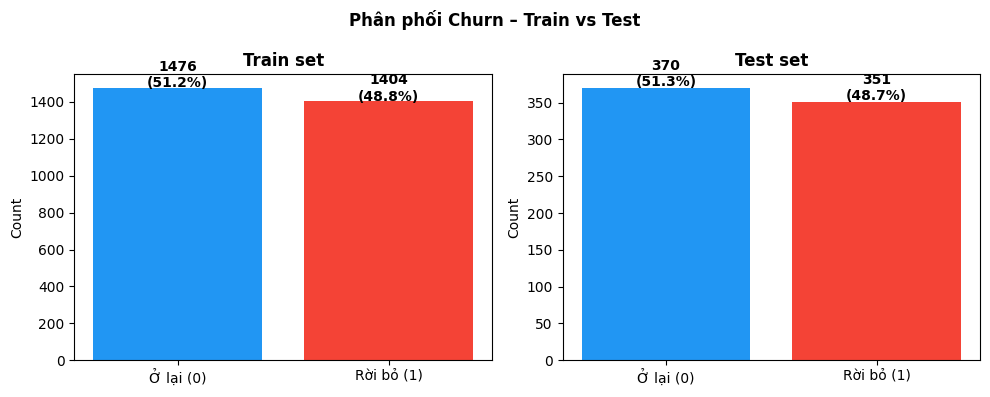

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train Churn ratio : {y_train.mean():.2%}")
print(f"Test  Churn ratio : {y_test.mean():.2%}")

# Visualize phân phối target trong Train vs Test
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, series, title in zip(
    axes,
    [y_train, y_test],
    ["Train set", "Test set"]
):
    counts = series.value_counts().sort_index()
    ax.bar(["Ở lại (0)", "Rời bỏ (1)"], counts.values, color=["#2196F3", "#F44336"])
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 3, f"{v}\n({v/len(series):.1%})", ha="center", fontweight="bold")
plt.suptitle("Phân phối Churn – Train vs Test", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 6 – Data Modelling

### Model 1: Logistic Regression
### Model 2: Decision Tree

In [9]:
# Bước 1: Log Transform – giảm skewness cho các feature lệch cao
# log1p = log(x + 1), an toàn với giá trị x = 0
X_train_log = np.log1p(X_train)
X_test_log  = np.log1p(X_test)

# Bước 2: StandardScaler – fit trên bản đã log, transform cả train lẫn test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)   # fit_transform trên TRAIN
X_test_scaled  = scaler.transform(X_test_log)         # chỉ transform trên TEST

# ── Model 1: Logistic Regression ──
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
print(" Logistic Regression đã được huấn luyện!")

 Logistic Regression đã được huấn luyện!


### Odds Ratio – Ý nghĩa hệ số Beta trong Logistic Regression

Công thức:
$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots$$

**Odds Ratio = exp(β)**:
- `exp(β) > 1` → tăng X thêm 1 đơn vị → **XÁC SUẤT CHURN TĂNG**
- `exp(β) < 1` → tăng X thêm 1 đơn vị → **XÁC SUẤT CHURN GIẢM**
- `exp(β) = 1` → không ảnh hưởng đến xác suất Churn

In [10]:
# Xem hệ số Beta và Odds Ratio
coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Beta (β)"   : lr.coef_[0],
    "Odds Ratio" : np.exp(lr.coef_[0])
}).sort_values("Odds Ratio", ascending=False).reset_index(drop=True)

display(coef_df.style.format({"Beta (β)": "{:.4f}", "Odds Ratio": "{:.4f}"}))

,Feature,Beta (β),Odds Ratio
0,Total_Spend,0.4942,1.6392
1,Total_Items,-0.0569,0.9447
2,Avg_Basket_Value,-0.2996,0.7412
3,Unique_Products,-0.4050,0.6670
4,Frequency,-1.1308,0.3228


In [11]:
# Decision Tree không cần scale hay log transform
# (Tree-based models không bị ảnh hưởng bởi scale/distribution)
dt = DecisionTreeClassifier(max_depth=4, random_state=42, criterion="entropy")
dt.fit(X_train, y_train)
print("✅ Decision Tree đã được huấn luyện!")

✅ Decision Tree đã được huấn luyện!


### Entropy trong Decision Tree

$$\text{Entropy} = -\sum_{i} p_i \cdot \log_2(p_i)$$

| Entropy | Ý nghĩa | Hành động |
|---------|---------|-----------|
| **= 0** | Node thuần túy (100% một class) | Dừng chia nhánh |
| **= 1** | Node hỗn hợp 50/50 | Cần chia tiếp |
| **0 < E < 1** | Node pha trộn | Tiếp tục xét |

**Information Gain** = Entropy(cha) − Entropy(con) → chọn feature có **IG lớn nhất** để chia

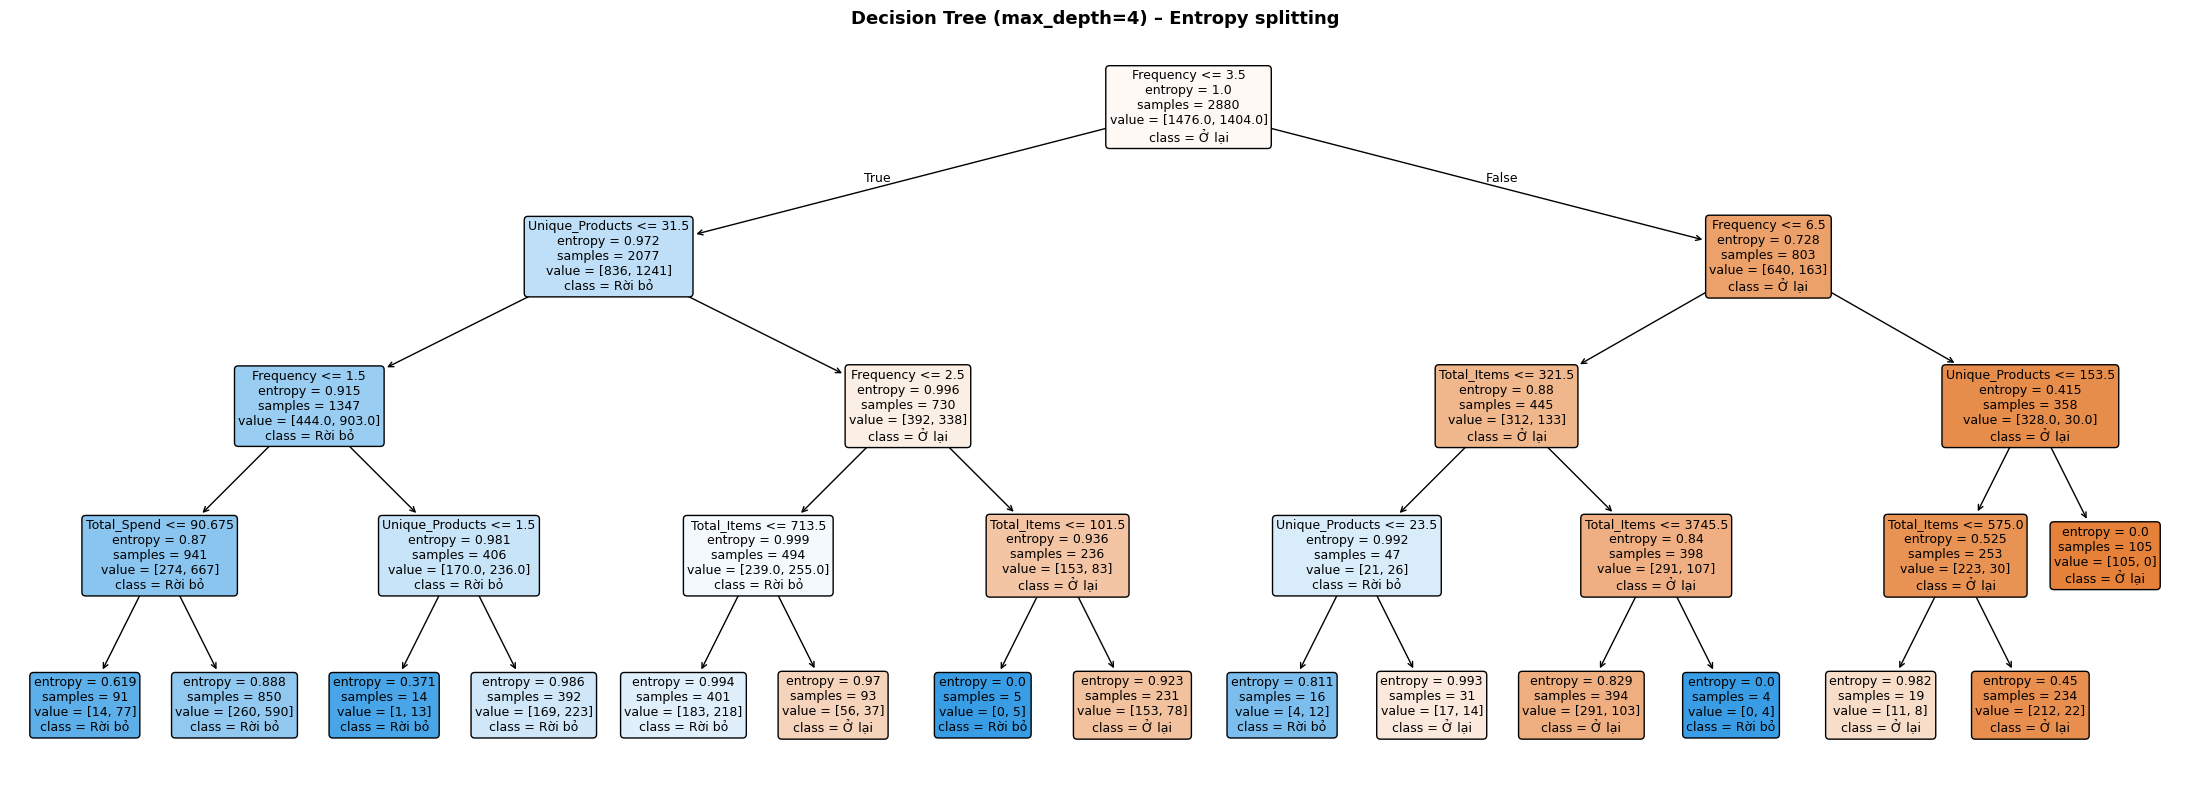

In [12]:
# Visualize cây quyết định
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=["Ở lại", "Rời bỏ"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree (max_depth=4) – Entropy splitting", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 7 – Data Evaluation

In [13]:
def evaluate_model(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)

    print(f"{'─'*45}")
    print(f" {name}")
    print(f"{'─'*45}")
    print(f"  Precision : {prec:.4f}  → Trong số dự đoán Churn, {prec:.1%} đúng")
    print(f"  Recall    : {rec:.4f}  → Bắt được {rec:.1%} khách thực sự Churn")
    print(f"  F1-Score  : {f1:.4f}  → Điểm tổng hợp Precision & Recall")
    print(f"  ROC-AUC   : {auc:.4f}  → Khả năng phân biệt 2 lớp")
    print()
    print(classification_report(y_te, y_pred, target_names=["Ở lại (0)", "Rời bỏ (1)"]))
    return y_pred, y_prob, {"Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}

# LR dùng X_test_scaled (đã qua log1p + StandardScaler)
# DT dùng X_test gốc (tree không cần scale)
y_pred_lr, y_prob_lr, metrics_lr = evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression (log1p + Scaled)")
y_pred_dt, y_prob_dt, metrics_dt = evaluate_model(dt, X_test,        y_test, "Decision Tree")


─────────────────────────────────────────────
 Logistic Regression (log1p + Scaled)
─────────────────────────────────────────────
  Precision : 0.6299  → Trong số dự đoán Churn, 63.0% đúng
  Recall    : 0.6838  → Bắt được 68.4% khách thực sự Churn
  F1-Score  : 0.6557  → Điểm tổng hợp Precision & Recall
  ROC-AUC   : 0.7236  → Khả năng phân biệt 2 lớp

              precision    recall  f1-score   support

   Ở lại (0)       0.67      0.62      0.65       370
  Rời bỏ (1)       0.63      0.68      0.66       351

    accuracy                           0.65       721
   macro avg       0.65      0.65      0.65       721
weighted avg       0.65      0.65      0.65       721

─────────────────────────────────────────────
 Decision Tree
─────────────────────────────────────────────
  Precision : 0.6355  → Trong số dự đoán Churn, 63.6% đúng
  Recall    : 0.7749  → Bắt được 77.5% khách thực sự Churn
  F1-Score  : 0.6983  → Điểm tổng hợp Precision & Recall
  ROC-AUC   : 0.7047  → Khả năng phâ

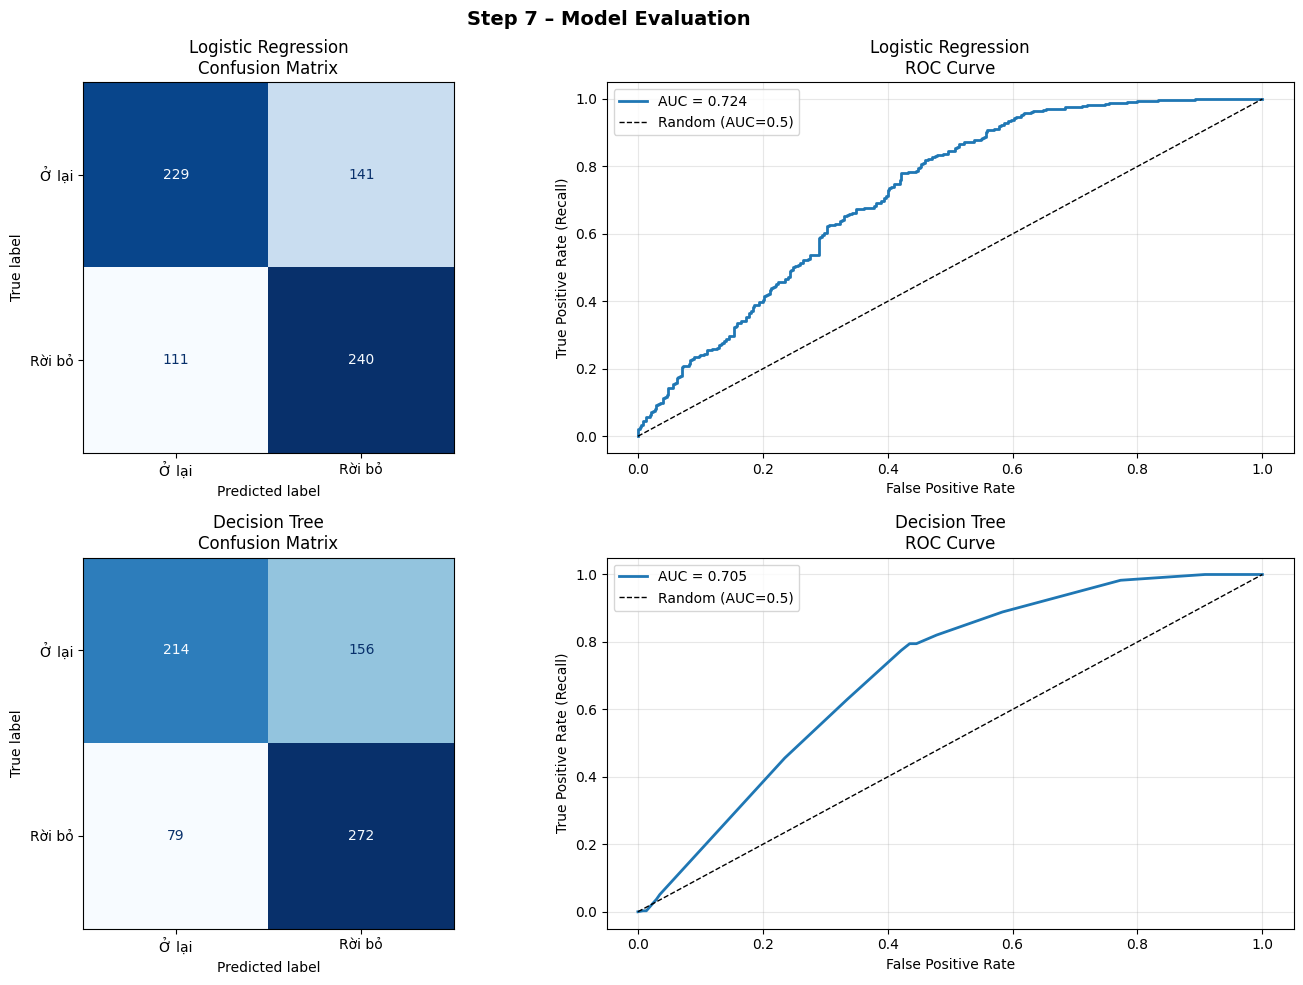

In [14]:
# Confusion Matrix + ROC Curve
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Step 7 – Model Evaluation", fontsize=14, fontweight="bold")

models_eval = [
    (y_pred_lr, y_prob_lr, "Logistic Regression"),
    (y_pred_dt, y_prob_dt, "Decision Tree"),
]

for idx, (y_pred, y_prob, name) in enumerate(models_eval):
    # Confusion Matrix
    ax_cm = axes[idx][0]
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                  display_labels=["Ở lại", "Rời bỏ"])
    disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
    ax_cm.set_title(f"{name}\nConfusion Matrix")

    # ROC Curve
    ax_roc = axes[idx][1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax_roc.plot(fpr, tpr, lw=2, label=f"AUC = {auc_val:.3f}")
    ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.5)")
    ax_roc.set_title(f"{name}\nROC Curve")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate (Recall)")
    ax_roc.legend()
    ax_roc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Biểu đồ 1 – Odds Ratio Plot

**Odds Ratio = exp(β)** cho biết mỗi feature tác động như thế nào lên xác suất Churn:
- `OR > 1` → Tăng feature → **tăng** xác suất Churn (màu đỏ)
- `OR < 1` → Tăng feature → **giảm** xác suất Churn (màu xanh)
- `OR = 1` → Không ảnh hưởng


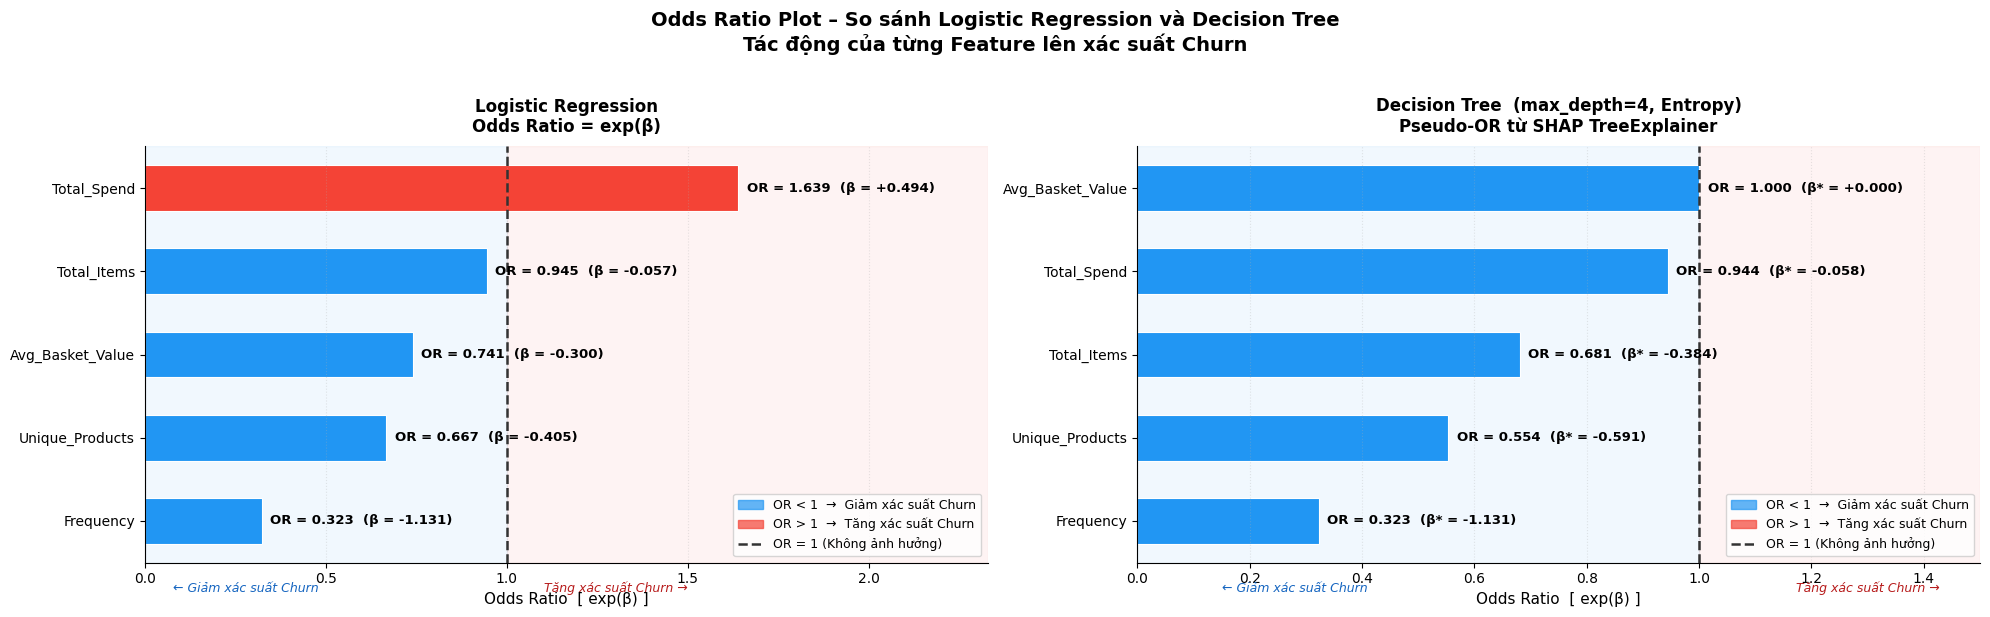

In [23]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FEATURES = ['Total_Spend', 'Frequency', 'Total_Items',
            'Unique_Products', 'Avg_Basket_Value']

# ── [1] LR: Odds Ratio từ coef ──
lr_coef_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Beta (β)'  : lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Odds Ratio').reset_index(drop=True)

# ── [2] DT: Pseudo-OR từ SHAP TreeExplainer ──
explainer = shap.TreeExplainer(dt)
sv = explainer.shap_values(X_test)[:, :, 1]   # class Churn=1

scale = (abs(float(lr.coef_[0][FEATURES.index('Frequency')])) /
         float(np.abs(sv[:, FEATURES.index('Frequency')]).mean()))

dt_results = []
for i, col in enumerate(FEATURES):
    mean_abs = float(np.abs(sv[:, i]).mean())
    if mean_abs < 1e-8:
        log_or = 0.0
    else:
        corr = float(np.corrcoef(X_test[col].values, sv[:, i])[0, 1])
        log_or = np.sign(0 if np.isnan(corr) else corr) * mean_abs * scale
    dt_results.append({'Feature': col, 'Odds Ratio': np.exp(log_or), 'Beta (β)': log_or})

dt_coef_df = pd.DataFrame(dt_results).sort_values('Odds Ratio').reset_index(drop=True)

# ── [3] Combined Plot ──
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Odds Ratio Plot – So sánh Logistic Regression và Decision Tree\n'
             'Tác động của từng Feature lên xác suất Churn',
             fontsize=14, fontweight='bold', y=1.02)

plot_data = [
    (axes[0], lr_coef_df,
     'Logistic Regression\nOdds Ratio = exp(β)',
     lambda val, beta: f'OR = {val:.3f}  (β = {"+" if beta>=0 else ""}{beta:.3f})'),
    (axes[1], dt_coef_df,
     'Decision Tree  (max_depth=4, Entropy)\nPseudo-OR từ SHAP TreeExplainer',
     lambda val, beta: f'OR = {val:.3f}  (β* = {"+" if beta>=0 else ""}{beta:.3f})'),
]

for ax, coef_df, title, label_fn in plot_data:
    colors = ['#F44336' if v > 1 else '#2196F3' for v in coef_df['Odds Ratio']]
    bars = ax.barh(coef_df['Feature'], coef_df['Odds Ratio'],
                   color=colors, height=0.55, edgecolor='white', linewidth=0.8)

    ax.axvline(x=1, color='#333333', linestyle='--', linewidth=1.8, zorder=3)

    x_max = max(coef_df['Odds Ratio'].max() * 1.42, 1.5)
    ax.axvspan(0, 1,     alpha=0.06, color='#2196F3', zorder=0)
    ax.axvspan(1, x_max, alpha=0.06, color='#F44336', zorder=0)

    for bar, val, beta in zip(bars, coef_df['Odds Ratio'], coef_df['Beta (β)']):
        ax.text(bar.get_width() + x_max * 0.01,
                bar.get_y() + bar.get_height() / 2,
                label_fn(val, beta), va='center', fontsize=9.5, fontweight='bold')

    ax.text(0.28, -0.85, '← Giảm xác suất Churn',
            transform=ax.transData, ha='center', fontsize=9, color='#1565C0', style='italic')
    ax.text(max(1.3, coef_df['Odds Ratio'].max() * 0.7), -0.85, 'Tăng xác suất Churn →',
            transform=ax.transData, ha='center', fontsize=9, color='#B71C1C', style='italic')

    patch_dec = mpatches.Patch(color='#2196F3', alpha=0.7, label='OR < 1  →  Giảm xác suất Churn')
    patch_inc = mpatches.Patch(color='#F44336', alpha=0.7, label='OR > 1  →  Tăng xác suất Churn')
    line_ref  = plt.Line2D([0], [0], color='#333', linestyle='--', linewidth=1.8,
                           label='OR = 1 (Không ảnh hưởng)')
    ax.legend(handles=[patch_dec, patch_inc, line_ref], loc='lower right', fontsize=9)

    ax.set_xlabel('Odds Ratio  [ exp(β) ]', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlim(0, x_max)
    ax.grid(axis='x', alpha=0.3, linestyle=':')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()